In [ ]:
#!git clone https://github.com/whyhardt/SPICE.git

In [ ]:
# !pip install -e SPICE

In [1]:
import sys

import torch

from spice import SpiceEstimator

sys.path.append("../../..")
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from weinhardt2026.studies.castro2025.benchmarking_castro2025 import Castro2025Model, get_dataset, generate_behavior
import spice_castro2025, weinhardt2026.studies.castro2025.spice_castro2025 as spice_castro2025

# NOTEBOOK CONFIG

In [2]:
train_spice = False
train_cfs = False
train_gru = False

## Load dataset

In [3]:
path_data = 'data/eckstein2024.csv'
test_sessions = (2,)  # pick sessions that exist for all participants; adjust if needed
dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_sessions=test_sessions, verbose=True)

Shape of dataset: torch.Size([4158, 150, 1, 13])
Number of participants: 862
Number of actions in dataset: 4


In [4]:
from spice import SpiceDataset

# keep only 100 timesteps
dataset_train = SpiceDataset(dataset_train.xs[:, :100], dataset_train.ys[:, :100])

# keep only 100 participants for rapid prototyping
keep_participants = torch.arange(0, 50)

def keep_subset(dataset, subset):
    participant_ids = dataset.xs[:, 0, 0, -1]
    mask = torch.isin(participant_ids, subset)
    return SpiceDataset(dataset.xs[mask], dataset.ys[mask])

dataset_train = keep_subset(dataset_train, keep_participants)
dataset_test = keep_subset(dataset_test, keep_participants)    


## SPICE Setup

## SPICE Training

Let's setup now the `SpiceEstimator` object and fit it to the data! 

We are going to do this in two steps:

1. Without fitting the SINDy coefficients to get the pure RNN performance given the selected architecture. 
2. With fitting SINDy coefficients to get the final performance of the interpretable model

That way we can disentangle the gap between GRU and SPICE w.r.t. architecture and SINDy library 

In [6]:
path_spice = 'params/spice_castro2025_62_stage1.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=spice_castro2025.SpiceModel,
        spice_config=spice_castro2025.CONFIG,
        n_actions=dataset_train.n_actions,
        n_participants=dataset_train.n_participants,
        
        epochs=1000,
        warmup_steps=250,

        verbose=True,
        # device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        save_path_spice=path_spice,
    )

In [6]:
if train_spice:
    estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

In [7]:
estimator.load_spice(path_spice)
# estimator.aggregate_coefficients()

In [8]:
# Print example SPICE model for first participant
print("\nExample SPICE model (participant 0):")
estimator.print_spice_model(participant_id=0)


Example SPICE model (participant 0):
value_reward_env[t+1]             = -0.009 1 + 0.964 value_reward_env[t] + 0.023 reward[t] 
value_reward_chosen[t+1]          = -0.432 1 + 0.922 value_reward_chosen[t] + -0.052 reward_env + 0.621 reward[t] + -0.095 value_reward_chosen*reward[t] + 0.012 reward_env^2 + 0.029 reward_env*reward[t] + 0.879 reward[t]^2 
value_reward_not_chosen[t+1]      = -0.044 1 + 0.808 value_reward_not_chosen[t] + 0.034 reward_env + 0.009 value_reward_mean 
value_choice_chosen[t+1]          = -0.356 1 + 0.432 value_choice_chosen[t] + 0.244 action[t-1] + 0.022 value_choice_chosen^2 + 0.054 value_choice_chosen*action[t-1] + 0.244 action[t-1]^2 
value_choice_not_chosen[t+1]      = 0.053 1 + 0.825 value_choice_not_chosen[t] + -0.585 action[t-1] + -0.067 value_choice_not_chosen^2 + -0.745 value_choice_not_chosen*action[t-1] + -0.586 action[t-1]^2 
value_exploration_chosen[t+1]     = -0.786 1 + 0.448 value_exploration_chosen[t] + 2.363 dvalue_pos + -2.634 dvalue_neg + -0.11

## Benchmarking

### Castro2025 benchmark model

In [7]:
path_spice = 'params/spice_castro2025.pkl'

# Benchmark model: Castro et al. 2025
cfs = Castro2025Model(
    n_participants=862,#dataset_train.n_participants,
    n_actions=dataset_train.n_actions,
    batch_first=True,
    )

path_cfs = path_spice.replace('spice_', 'cfs_')

In [8]:
if train_cfs:
    optimizer_cfs = torch.optim.Adam(params=cfs.parameters(), lr=0.01)
    epochs = 1000

    cfs = training(
        model=cfs,
        optimizer=optimizer_cfs,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        loss_kwargs={'label_smoothing': 0.0},
    )

    torch.save(cfs.state_dict(), path_cfs)

In [9]:
cfs.load_state_dict(torch.load(path_cfs, map_location='cpu'))

<All keys matched successfully>

### GRU Model

In [10]:
gru = GRUModel(
    n_actions=dataset_train.n_actions, 
    additional_inputs=2, 
    dropout=0.1,
    hidden_size=32,
    )
path_gru = path_spice.replace('spice_', 'gru_')

In [11]:
if train_gru:
    epochs = 1000
    optimizer_gru = torch.optim.Adam(gru.parameters(), lr=0.01)

    gru = training(
        model=gru,
        optimizer=optimizer_gru,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        loss_kwargs={'label_smoothing': 0.0},
        ).to(torch.device('cpu'))

    torch.save(gru.state_dict(), path_gru)

In [12]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))

<All keys matched successfully>

# ANALYSIS

In [13]:
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from analysis_generative import analysis_generative_behavior

In [15]:
# estimator.eval()
cfs.eval()
gru.eval()

GRUModel(
  (participant_embedding): Embedding(1, 16)
  (experiment_embedding): Embedding(1, 16)
  (linear_in): Linear(in_features=10, out_features=32, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (gru): GRU(32, 32, batch_first=True)
  (linear_out): Linear(in_features=32, out_features=4, bias=True)
)

## General Analysis

In [17]:
# Dataset-specific behavioral analysis placeholder.
# Replace with Eckstein2024-specific columns if needed.

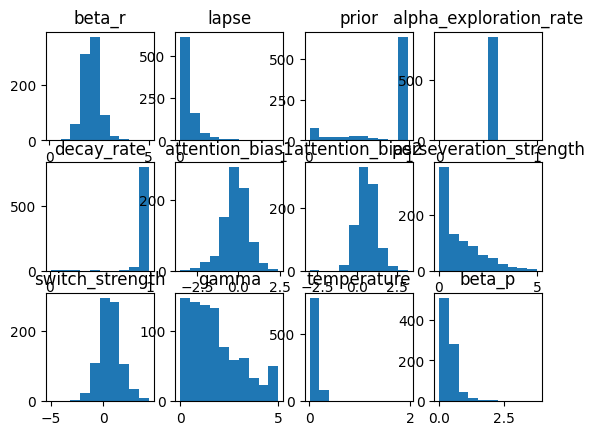

In [16]:
import matplotlib.pyplot as plt

list_parameters_cfs = [
    'beta_r', 
    'lapse', 
    'prior', 
    'alpha_exploration_rate', 
    'decay_rate', 
    'attention_bias1', 
    'attention_bias2', 
    'perseveration_strength', 
    'switch_strength', 
    'gamma', 
    'temperature', 
    'beta_p',
    ]
fig, axs = plt.subplots(3, 4)
for i in range(len(list_parameters_cfs)):
    row = i//4
    col = i%4
    axs[row, col].hist(getattr(cfs, list_parameters_cfs[i]).detach().cpu().numpy())
    axs[row, col].set_title(list_parameters_cfs[i])
plt.show()


## Analysis Model Evaluation

In [17]:
analysis_model_evaluation(
    dataset=dataset_train,
    # spice_model=estimator,
    benchmark_model=cfs.to(torch.device('cpu')),
    gru_model=gru.eval().to(torch.device('cpu')),
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.657097,0.160410,13.0,0.0,7875.657715,15777.315430,15879.225586
GRU,0.665337,0.150873,6852.0,0.0,7641.947266,28987.894531,82702.203125
SPICE-RNN,1.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000
SPICE,1.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000


In [19]:
analysis_model_evaluation(
    dataset=dataset_test,
    # spice_model=estimator,
    benchmark_model=cfs.to(torch.device('cpu')),
    gru_model=gru.eval().to(torch.device('cpu')),
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.638252,0.176855,13.0,0.0,3329.946289,6685.892578,6775.740723
GRU,0.663272,0.161131,6852.0,0.0,3044.788086,19793.576172,67150.453125
SPICE-RNN,1.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000
SPICE,1.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000


## Analysis generative behavior

In [ ]:
estimator.use_sindy(True)
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_spice.csv'
)

estimator.use_sindy(False)
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_spice_rnn.csv'
)

gru.eval()
generate_behavior(
    model=gru,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_gru.csv'
)

generate_behavior(
    model=cfs,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_cfs.csv'
)

In [ ]:
analysis_generative_behavior(
    path_data_real=path_data,
    path_data_gru='data/eckstein2024_gru.csv',
    path_data_benchmark='data/eckstein2024_cfs.csv',
    path_data_spice='data/eckstein2024_spice.csv',
    path_data_spice_rnn='data/eckstein2024_spice_rnn.csv',
    output_dir='results',
)

## Analysis coefficient distributions

In [ ]:
# analysis_coefficients_distributions(
#     spice_model=estimator,
#     output_dir='results',
# )

## Analysis Individual Differences

In [ ]:
# analysis_coefficients_individuals(
#     criterion="SomeCriterionColumnInYourDataset",
#     analysis="disc",  # also: "cont"
#     reference="ReferenceGroupFromCriterionColumn",  # only necessary if analysis="disc"
    
#     path_data=path_file,
    
#     spice_model=estimator,
    
#     dir_output='results',
# )